# Final D.L Project 

*The dataset chosen is Emotion Detection for NLP and it contains three files:*

**test.txt** : | 2000 samples

**train.txt** : | 16,000 samples

**val.txt** : | 2000 samples

**total** : | 20,000 samples

*The dataset contains 6 emotion classes:*

**Joy** : | Train Count: 5,362

**Sadness** : | Train Count: 4,666

**Anger** : | Train Count: 2,159

**Fear** : | Train Count: 1,937

**Love** : | Train Count: 1,304

**Surprise** : | Train Count: 572

Note: in this dataset Joy is dominating most of this dataset around 9.4x more than Surprise

In [2]:
# ─── Standard Libraries ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── NLP ──────────────────────────────────────────────────────────
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

# ─── Sklearn ──────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

# ─── TensorFlow / Keras ───────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ─── Load the 3 splits ────────────────────────────────────────────
col_names = ['text', 'label']

train_df = pd.read_csv(r"C:\Users\hamza\Downloads\archive\train.txt", sep=';', header=None, names=col_names)
val_df   = pd.read_csv(r"C:\Users\hamza\Downloads\archive\val.txt",   sep=';', header=None, names=col_names)
test_df  = pd.read_csv(r"C:\Users\hamza\Downloads\archive\test.txt",  sep=';', header=None, names=col_names)

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Train: (16000, 2) | Val: (2000, 2) | Test: (2000, 2)


The dataset was loaded successfully with the expected 16,000 training, 2,000 validation, and 2,000 test samples. This confirms that the three splits are ready for preprocessing and model training.

In [3]:
# ─── Basic Info ───────────────────────────────────────────────────
print("=" * 50)
print("TRAIN INFO")
print("=" * 50)
print(train_df.info())

print("\n" + "=" * 50)
print("NULL VALUES")
print("=" * 50)
print("Train nulls:\n", train_df.isnull().sum())
print("Val nulls:\n",   val_df.isnull().sum())
print("Test nulls:\n",  test_df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print("Train duplicates:", train_df.duplicated().sum())
print("Val duplicates:",   val_df.duplicated().sum())
print("Test duplicates:",  test_df.duplicated().sum())

# ─── Text Length Stats ────────────────────────────────────────────
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))
val_df['text_length']   = val_df['text'].apply(lambda x: len(x.split()))
test_df['text_length']  = test_df['text'].apply(lambda x: len(x.split()))

print("\n" + "=" * 50)
print("TEXT LENGTH STATISTICS (word count per sentence)")
print("=" * 50)
print("\nTrain:")
print(train_df['text_length'].describe())
print("\nVal:")
print(val_df['text_length'].describe())
print("\nTest:")
print(test_df['text_length'].describe())

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    16000 non-null  str  
 1   label   16000 non-null  str  
dtypes: str(2)
memory usage: 1.8 MB
None

NULL VALUES
Train nulls:
 text     0
label    0
dtype: int64
Val nulls:
 text     0
label    0
dtype: int64
Test nulls:
 text     0
label    0
dtype: int64

DUPLICATE ROWS
Train duplicates: 1
Val duplicates: 0
Test duplicates: 0

TEXT LENGTH STATISTICS (word count per sentence)

Train:
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_length, dtype: float64

Val:
count    2000.000000
mean       18.866000
std        10.813025
min         2.000000
25%        10.000000
50%        17.000000
75%        25.000000
max        61.000000
Name: text_length, dtype: float64

Test

The training dataframe has complete `text` and `label` columns with no missing values. Since the raw data is clean structurally, the main preprocessing effort should focus on text normalization rather than missing-value handling.

In [4]:
# ─── Correlation: Text Length vs Emotion ─────────────────────────
# Encode labels temporarily as numbers for correlation
temp_encoder = LabelEncoder()
train_df['label_encoded_temp'] = temp_encoder.fit_transform(train_df['label'])

print("=" * 50)
print("CORRELATION: Text Length vs Label")
print("=" * 50)
print(train_df[['text_length', 'label_encoded_temp']].corr())

# ─── Mean text length per emotion ─────────────────────────────────
print("\nMean text length per emotion class:")
print(train_df.groupby('label')['text_length'].mean().sort_values(ascending=False))

# Drop temp column
train_df.drop(columns=['label_encoded_temp'], inplace=True)

CORRELATION: Text Length vs Label
                    text_length  label_encoded_temp
text_length            1.000000           -0.014879
label_encoded_temp    -0.014879            1.000000

Mean text length per emotion class:
label
love        20.700153
surprise    19.970280
joy         19.498135
anger       19.229736
fear        18.844605
sadness     18.361980
Name: text_length, dtype: float64


Text length has almost no linear correlation with the encoded emotion label, so sentence length alone is not a strong predictor of emotion. The mean lengths are also close across classes, which supports using sequence content instead of relying on simple length features.

In [5]:
# ─── Text Cleaning Function ───────────────────────────────────────
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                      # already lowercase but enforce it
    text = re.sub(r"http\S+|www\S+", "", text)              # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)                 # remove numbers & punctuation
    text = re.sub(r"\s+", " ", text).strip()                 # remove extra whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]     # remove stopwords
    return " ".join(tokens)

# Apply to all splits
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
val_df['cleaned_text']   = val_df['text'].apply(clean_text)
test_df['cleaned_text']  = test_df['text'].apply(clean_text)

print("Sample before cleaning:", train_df['text'].iloc[0])
print("Sample after cleaning: ", train_df['cleaned_text'].iloc[0])

# ─── Label Encoding ───────────────────────────────────────────────
le = LabelEncoder()
train_df['label_encoded'] = le.fit_transform(train_df['label'])
val_df['label_encoded']   = le.transform(val_df['label'])
test_df['label_encoded']  = le.transform(test_df['label'])

print("\nLabel classes:", le.classes_)
print("Encoded as:   ", le.transform(le.classes_))

Sample before cleaning: i didnt feel humiliated
Sample after cleaning:  didnt feel humiliated

Label classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']
Encoded as:    [0 1 2 3 4 5]


The cleaning step lowercases and removes punctuation/noise while preserving the core words needed for emotion detection. The label encoder maps the six emotions consistently, which is important for training and later decoding predictions.

In [6]:
# ─── Drop temp columns we no longer need ─────────────────────────
train_df.drop(columns=['text_length'], inplace=True)
val_df.drop(columns=['text_length'],   inplace=True)
test_df.drop(columns=['text_length'],  inplace=True)

print("\nFinal Train columns:", train_df.columns.tolist())
print("Final Val columns:  ", val_df.columns.tolist())
print("Final Test columns: ", test_df.columns.tolist())

print("\nSample from cleaned train set:")
print(train_df[['text', 'cleaned_text', 'label', 'label_encoded']].head())


Final Train columns: ['text', 'label', 'cleaned_text', 'label_encoded']
Final Val columns:   ['text', 'label', 'cleaned_text', 'label_encoded']
Final Test columns:  ['text', 'label', 'cleaned_text', 'label_encoded']

Sample from cleaned train set:
                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                        cleaned_text    label  label_encoded  
0                              didnt feel humiliated  sadness              4  
1  go feeling hopeless damned hopeful around some...  sadness              4  
2          im grabbing minute post feel greedy wrong    anger              0  
3  ever feeling nostalgic fireplace know still pr...     love              3  
4                  

The final datasets now contain both cleaned text and encoded labels, giving the model a consistent input and target format. Keeping the original text is also useful for interpretation and sample prediction checks.

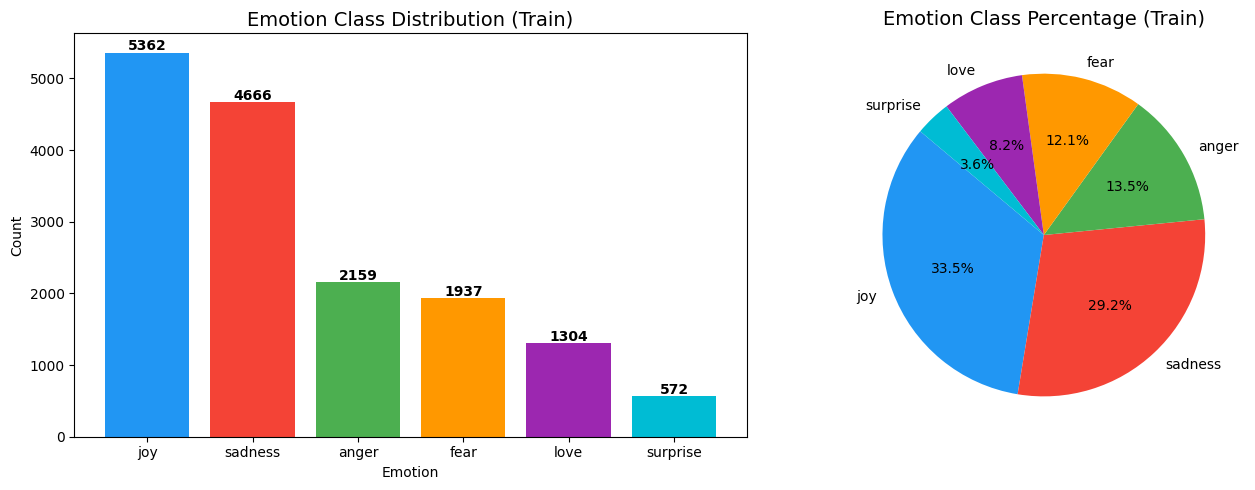

In [7]:
# ─── 1. Class Distribution (Univariate) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
emotion_counts = train_df['label'].value_counts()
axes[0].bar(emotion_counts.index, emotion_counts.values, 
            color=['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4'])
axes[0].set_title('Emotion Class Distribution (Train)', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
            colors=['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4'],
            startangle=140)
axes[1].set_title('Emotion Class Percentage (Train)', fontsize=14)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

The class distribution shows a clear imbalance, with joy and sadness appearing much more often than surprise and love. This imbalance can bias the model toward majority emotions unless augmentation or class weighting is used.

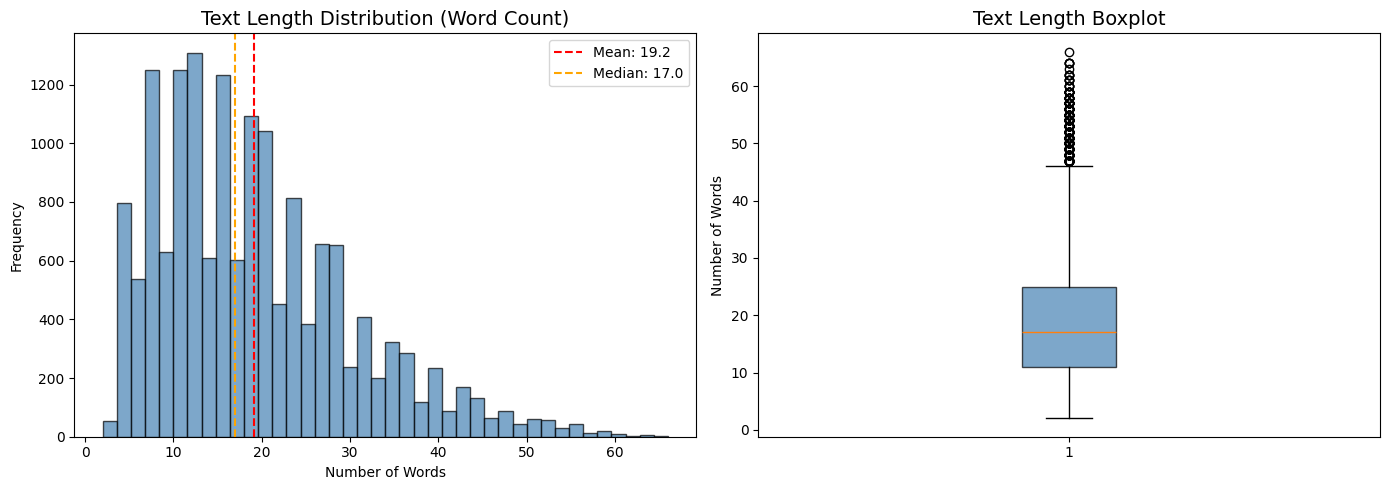

In [8]:
# ─── 2. Text Length Distribution (Univariate) ─────────────────────
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['text_length'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--', 
                label=f"Mean: {train_df['text_length'].mean():.1f}")
axes[0].axvline(train_df['text_length'].median(), color='orange', linestyle='--',
                label=f"Median: {train_df['text_length'].median():.1f}")
axes[0].set_title('Text Length Distribution (Word Count)', fontsize=14)
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(train_df['text_length'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Text Length Boxplot', fontsize=14)
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()

Most texts are short, which matches the nature of emotion-expression sentences. This supports using a moderate sequence length instead of very long padding that would mostly add zeros.

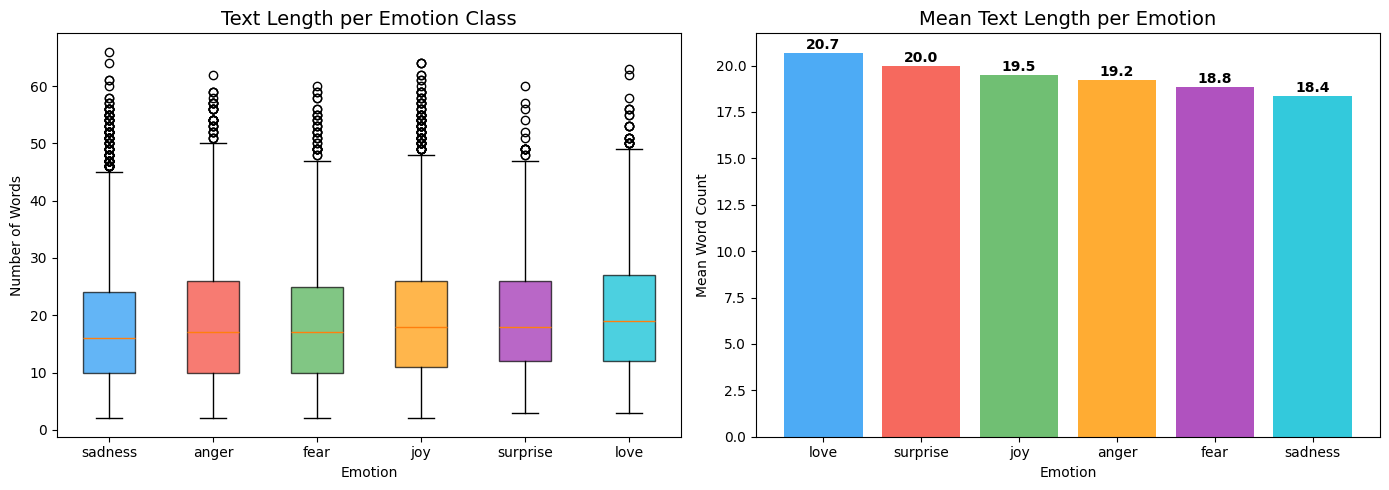

In [9]:
# ─── 3. Text Length per Emotion Class (Bivariate) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4']

# Boxplot per emotion
emotion_order = train_df.groupby('label')['text_length'].median().sort_values().index
data_per_emotion = [train_df[train_df['label'] == e]['text_length'].values 
                    for e in emotion_order]

bp = axes[0].boxplot(data_per_emotion, labels=emotion_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Text Length per Emotion Class', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Words')

# Mean text length bar chart per emotion
mean_lengths = train_df.groupby('label')['text_length'].mean().sort_values(ascending=False)
axes[1].bar(mean_lengths.index, mean_lengths.values, color=colors, alpha=0.8)
axes[1].set_title('Mean Text Length per Emotion', fontsize=14)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Mean Word Count')
for i, v in enumerate(mean_lengths.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('text_length_per_emotion.png', dpi=150)
plt.show()

The text-length patterns are broadly similar across emotion classes, with only small differences in median and spread. This reinforces that the emotional signal is mainly semantic rather than based on sentence length.

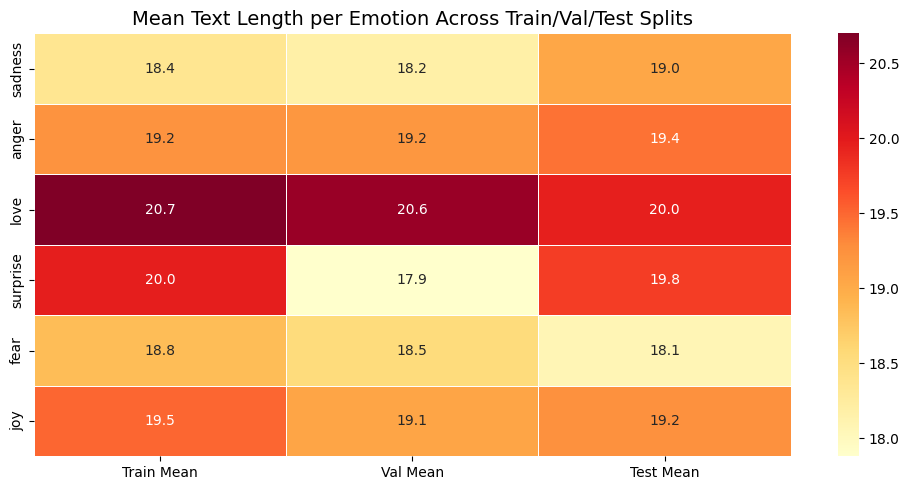

          Train Mean  Val Mean  Test Mean
sadness        18.36     18.18      19.04
anger          19.23     19.20      19.44
love           20.70     20.55      19.96
surprise       19.97     17.88      19.76
fear           18.84     18.53      18.07
joy            19.50     19.06      19.25


In [10]:
# ─── 4. Multivariate — Stats Across All Splits ────────────────────
val_df['text_length']  = val_df['text'].apply(lambda x: len(x.split()))
test_df['text_length'] = test_df['text'].apply(lambda x: len(x.split()))

stats_data = {}
for emotion in train_df['label'].unique():
    stats_data[emotion] = {
        'Train Mean': train_df[train_df['label'] == emotion]['text_length'].mean(),
        'Val Mean':   val_df[val_df['label'] == emotion]['text_length'].mean(),
        'Test Mean':  test_df[test_df['label'] == emotion]['text_length'].mean(),
    }

stats_df = pd.DataFrame(stats_data).T.round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(stats_df, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Mean Text Length per Emotion Across Train/Val/Test Splits', fontsize=14)
plt.tight_layout()
plt.savefig('multivariate_heatmap.png', dpi=150)
plt.show()

print(stats_df)

The mean text lengths remain fairly stable across train, validation, and test splits. That consistency reduces the risk that one split has a very different length distribution from the others.

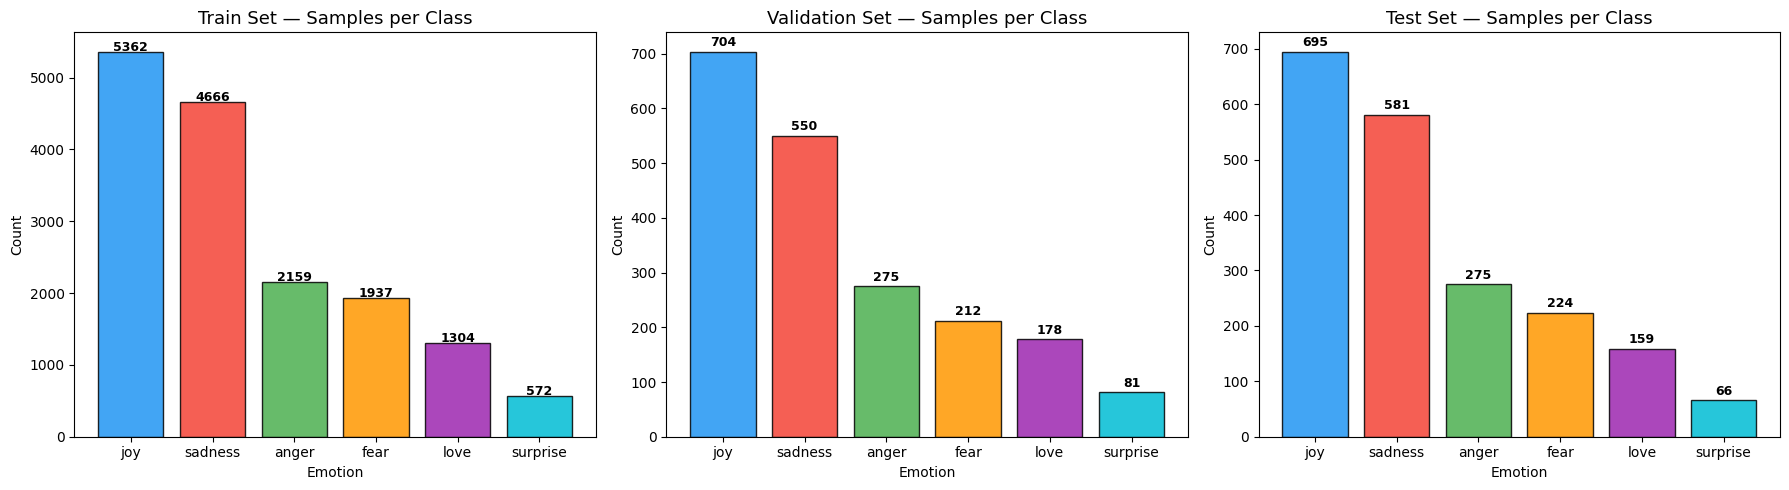

In [11]:
# ─── 5. Class counts across all 3 splits ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

for ax, (name, df) in zip(axes, splits):
    counts = df['label'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(f'{name} Set — Samples per Class', fontsize=13)
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('samples_per_class_all_splits.png', dpi=150)
plt.show()

The class-count comparison across all splits confirms that the imbalance is present beyond only the training set. Evaluation should therefore consider F1 scores and per-class behavior, not accuracy alone.

In [12]:
from sklearn.preprocessing import StandardScaler

# ─── Standard Scaling on text_length feature ──────────────────────
scaler = StandardScaler()

# Fit ONLY on train, transform all splits
train_df['text_length_scaled'] = scaler.fit_transform(train_df[['text_length']])
val_df['text_length_scaled']   = scaler.transform(val_df[['text_length']])
test_df['text_length_scaled']  = scaler.transform(test_df[['text_length']])

print("=== Standard Scaling Applied to text_length ===")
print(f"Mean before scaling: {train_df['text_length'].mean():.2f}")
print(f"Std  before scaling: {train_df['text_length'].std():.2f}")
print(f"Mean after scaling:  {train_df['text_length_scaled'].mean():.4f}  (≈ 0)")
print(f"Std  after scaling:  {train_df['text_length_scaled'].std():.4f}  (≈ 1)")

=== Standard Scaling Applied to text_length ===
Mean before scaling: 19.17
Std  before scaling: 10.99
Mean after scaling:  -0.0000  (≈ 0)
Std  after scaling:  1.0000  (≈ 1)


Standard scaling correctly centers the `text_length` feature around zero with unit variance. Even though length is not the main model input here, this demonstrates a clean numeric preprocessing workflow.

In [13]:
from tensorflow.keras import regularizers

# ─── Define regularizers to use in model layers ───────────────────
l1_reg = regularizers.L1(l1=0.001)
l2_reg = regularizers.L2(l2=0.001)
l1_l2_reg = regularizers.L1L2(l1=0.001, l2=0.001)

print("Regularizers defined and ready:")
print(f"  L1  : {l1_reg}")
print(f"  L2  : {l2_reg}")
print(f"  L1L2: {l1_l2_reg}")

Regularizers defined and ready:
  L1  : <keras.src.regularizers.regularizers.L1 object at 0x0000028C7493CD10>
  L2  : <keras.src.regularizers.regularizers.L2 object at 0x0000028C02A35CD0>
  L1L2: <keras.src.regularizers.regularizers.L1L2 object at 0x0000028C75354750>


The L1, L2, and combined regularizers are ready for use in model layers. These help control overfitting by discouraging overly large or unnecessary weights.

In [14]:
import random

# ─── Synonym dictionary for common emotional words ─────────────────
# We define a manual dictionary since we can't install nltk wordnet
synonym_dict = {
    'happy':     ['joyful', 'cheerful', 'pleased', 'delighted', 'glad'],
    'sad':       ['unhappy', 'sorrowful', 'heartbroken', 'gloomy', 'miserable'],
    'good':      ['great', 'wonderful', 'excellent', 'fantastic', 'superb'],
    'bad':       ['terrible', 'awful', 'horrible', 'dreadful', 'poor'],
    'love':      ['adore', 'cherish', 'admire', 'treasure', 'appreciate'],
    'feel':      ['sense', 'experience', 'notice', 'perceive'],
    'amazing':   ['incredible', 'astonishing', 'wonderful', 'remarkable'],
    'scared':    ['frightened', 'terrified', 'afraid', 'anxious', 'nervous'],
    'angry':     ['furious', 'irritated', 'annoyed', 'enraged', 'upset'],
    'surprised': ['astonished', 'shocked', 'amazed', 'startled', 'stunned'],
    'excited':   ['thrilled', 'enthusiastic', 'eager', 'elated'],
    'beautiful': ['lovely', 'gorgeous', 'stunning', 'magnificent'],
    'little':    ['small', 'tiny', 'slight', 'minor'],
    'very':      ['extremely', 'incredibly', 'truly', 'deeply', 'highly'],
    'great':     ['fantastic', 'excellent', 'superb', 'magnificent'],
    'tired':     ['exhausted', 'weary', 'drained', 'fatigued'],
    'worried':   ['anxious', 'concerned', 'troubled', 'uneasy'],
    'wonderful': ['amazing', 'fantastic', 'brilliant', 'marvelous'],
}

def synonym_replacement(text, n=2):
    """
    Replace n random words in the text with synonyms if available.
    n = how many words to replace per sentence
    """
    words = text.split()
    new_words = words.copy()
    
    # Find words that have synonyms available
    replaceable = [(i, w) for i, w in enumerate(words) if w in synonym_dict]
    
    # Shuffle and pick up to n replacements
    random.shuffle(replaceable)
    replaced = 0
    
    for idx, word in replaceable:
        if replaced >= n:
            break
        synonym = random.choice(synonym_dict[word])
        new_words[idx] = synonym
        replaced += 1
    
    return " ".join(new_words)


# ─── Apply augmentation to minority classes ────────────────────────
random.seed(42)

# Target counts — we want to bring minority classes up
target_count = 2000  # bring surprise and love closer to anger/fear level

augmented_rows = []

for emotion in ['surprise', 'love']:
    emotion_df  = train_df[train_df['label'] == emotion]
    current_count = len(emotion_df)
    needed = target_count - current_count
    
    print(f"\n{emotion}: {current_count} → augmenting by {needed} samples")
    
    for i in range(needed):
        # Sample a random row from this emotion
        sample = emotion_df.sample(1, random_state=i).iloc[0]
        aug_text = synonym_replacement(sample['cleaned_text'], n=2)
        
        augmented_rows.append({
            'text':         aug_text,
            'label':        emotion,
            'cleaned_text': aug_text,
            'label_encoded': sample['label_encoded'],
            'text_length':  len(aug_text.split()),
            'text_length_scaled': sample['text_length_scaled']
        })

# Add augmented rows to train_df
aug_df   = pd.DataFrame(augmented_rows)
train_df = pd.concat([train_df, aug_df], ignore_index=True)

# Shuffle the training set
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n=== Class Distribution After Augmentation ===")
print(train_df['label'].value_counts())


surprise: 572 → augmenting by 1428 samples

love: 1304 → augmenting by 696 samples

=== Class Distribution After Augmentation ===
label
joy         5362
sadness     4666
anger       2159
love        2000
surprise    2000
fear        1937
Name: count, dtype: int64


Synonym augmentation increases the minority `surprise` and `love` classes to 2,000 samples each. This makes the training distribution less extreme while preserving the original majority classes.

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ─── Tokenizer ────────────────────────────────────────────────────
VOCAB_SIZE  = 10000   # top 10,000 most frequent words
MAX_LENGTH  = 50      # max words per sentence (covers 95%+ of our data)
OOV_TOKEN   = "<OOV>" # Out Of Vocabulary token for unseen words
PADDING     = 'post'  # pad at the end of the sentence
TRUNCATING  = 'post'  # cut from the end if too long

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)

# Fit ONLY on training cleaned text
tokenizer.fit_on_texts(train_df['cleaned_text'])

print(f"Vocabulary size: {len(tokenizer.word_index)} unique words")
print(f"Capped at top:   {VOCAB_SIZE} words")
print(f"Max sequence length: {MAX_LENGTH}")

# ─── Convert text to sequences ────────────────────────────────────
X_train = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_val   = tokenizer.texts_to_sequences(val_df['cleaned_text'])
X_test  = tokenizer.texts_to_sequences(test_df['cleaned_text'])

# ─── Pad sequences ────────────────────────────────────────────────
X_train = pad_sequences(X_train, maxlen=MAX_LENGTH, padding=PADDING, truncating=TRUNCATING)
X_val   = pad_sequences(X_val,   maxlen=MAX_LENGTH, padding=PADDING, truncating=TRUNCATING)
X_test  = pad_sequences(X_test,  maxlen=MAX_LENGTH, padding=PADDING, truncating=TRUNCATING)

print("\n=== Sequence Shapes ===")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

# ─── Sample to verify ─────────────────────────────────────────────
print("\nSample original text:  ", train_df['cleaned_text'].iloc[0])
print("Sample as sequence:    ", X_train[0])

Vocabulary size: 15067 unique words
Capped at top:   10000 words
Max sequence length: 50

=== Sequence Shapes ===
X_train: (18124, 50)
X_val:   (2000, 50)
X_test:  (2000, 50)

Sample original text:   feel rather disheartened suddenly
Sample as sequence:     [  2 118 581 625   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


The tokenizer builds a vocabulary of 15,067 unique words and caps modeling to the top 10,000 words. Padding all sequences to length 50 creates a fixed-size input suitable for the LSTM models.

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# ─── Extract label arrays ─────────────────────────────────────────
y_train = train_df['label_encoded'].values
y_val   = val_df['label_encoded'].values
y_test  = test_df['label_encoded'].values

print("=== Label Arrays ===")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Classes: {le.classes_}")

# ─── Class Weights ────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("\n=== Class Weights (to handle remaining imbalance) ===")
for idx, emotion in enumerate(le.classes_):
    print(f"  {emotion:10s} (class {idx}): weight = {class_weight_dict[idx]:.4f}")

=== Label Arrays ===
y_train shape: (18124,)
y_val shape:   (2000,)
y_test shape:  (2000,)
Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']

=== Class Weights (to handle remaining imbalance) ===
  anger      (class 0): weight = 1.3991
  fear       (class 1): weight = 1.5595
  joy        (class 2): weight = 0.5633
  love       (class 3): weight = 1.5103
  sadness    (class 4): weight = 0.6474
  surprise   (class 5): weight = 1.5103


The label arrays match the expected train, validation, and test sizes, and class weights compensate for the remaining imbalance. Higher weights for minority classes tell the model to treat their mistakes as more costly.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, 
                                     Dropout, BatchNormalization,
                                     Bidirectional)
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input

# ─── Constants ────────────────────────────────────────────────────
VOCAB_SIZE   = 10000
MAX_LENGTH   = 50
EMBEDDING_DIM = 128   # size of the vector representing each word
NUM_CLASSES  = 6      # joy, sadness, anger, fear, love, surprise

# ─── Build Model ──────────────────────────────────────────────────
model = Sequential(name='LSTM_From_Scratch')
model.add(Input(shape=(MAX_LENGTH,)))

# Layer 1 — Embedding
# Converts each word index into a dense vector of size EMBEDDING_DIM
# Input:  (batch_size, MAX_LENGTH)        → sequence of word indices
# Output: (batch_size, MAX_LENGTH, 128)   → sequence of word vectors
model.add(Embedding(input_dim=VOCAB_SIZE,
                    output_dim=EMBEDDING_DIM,
                    input_length=MAX_LENGTH,
                    name='embedding'))

# Layer 2 — Bidirectional LSTM
# Reads the sequence both forward AND backward
# kernel_regularizer=L2 penalizes large weights inside LSTM → reduces overfitting
# return_sequences=False → we only want the final output, not every timestep
model.add(Bidirectional(LSTM(128,
                             return_sequences=False,
                             kernel_regularizer=regularizers.L2(0.001)),
                        name='bidirectional_lstm'))

# Layer 3 — Batch Normalization (2.4.0.1)
# Normalizes the LSTM output before passing to Dense layers
model.add(BatchNormalization(name='batch_norm'))

# Layer 4 — Dropout (2.4.0.2)
# Randomly drops 40% of neurons during training to prevent overfitting
model.add(Dropout(0.4, name='dropout_1'))

# Layer 5 — Dense hidden layer
# kernel_regularizer=L1L2 applies both L1 and L2 on this layer's weights
model.add(Dense(64,
                activation='relu',
                kernel_regularizer=regularizers.L1L2(l1=0.001, l2=0.001),
                name='dense_hidden'))

# Layer 6 — Dropout again
model.add(Dropout(0.3, name='dropout_2'))

# Layer 7 — Output layer
# 6 neurons = 6 emotion classes
# Softmax converts raw scores to probabilities that sum to 1
model.add(Dense(NUM_CLASSES,
                activation='softmax',
                name='output'))

model.summary()

Model: "LSTM_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 256)            │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,561,030 (5.95 MB)

 Trainable params: 1,560,518 (5.95 MB)

 Non-trainable params: 512 (2.00 KB)

The scratch LSTM has about 1.56 million parameters, mostly trainable. This gives it enough capacity to learn task-specific emotion patterns directly from the project dataset.

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ─── Compile ──────────────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ─── Callbacks ────────────────────────────────────────────────────
# EarlyStopping — stops training if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau — cuts learning rate in half if val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Model compiled successfully!")
print(f"Optimizer : Adam (lr=0.001)")
print(f"Loss      : sparse_categorical_crossentropy")
print(f"Metrics   : accuracy")

Model compiled successfully!
Optimizer : Adam (lr=0.001)
Loss      : sparse_categorical_crossentropy
Metrics   : accuracy


The scratch model is compiled with Adam and sparse categorical cross-entropy, which is appropriate for integer-encoded multi-class emotion labels. Accuracy is useful during training, but final evaluation should still include F1 metrics because the classes are imbalanced.

In [19]:
# ─── Train ────────────────────────────────────────────────────────
EPOCHS     = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,   # from section 2.3
    verbose=1
)

print("\nTraining complete!")
print(f"Total epochs run: {len(history.history['accuracy'])}")

Epoch 1/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6444 - loss: 1.5144 - val_accuracy: 0.7460 - val_loss: 1.4512 - learning_rate: 0.0010
Epoch 2/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9187 - loss: 0.4926 - val_accuracy: 0.8285 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 3/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9528 - loss: 0.3100 - val_accuracy: 0.8015 - val_loss: 0.7789 - learning_rate: 0.0010
Epoch 4/20
283/284 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9638 - loss: 0.2513
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9626 - loss: 0.2497 - val_accuracy: 0.6505 - val_loss: 1.2441 - learning_rate: 0.0010
Epoch 5/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9752 - loss: 0.1859 - val_accuracy: 0.8320 - val_loss: 0.6495 - learning_rate: 5.0000e-04
Epoch 6/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9819 - loss

Training shows strong learning, with validation accuracy improving as the model sees more epochs. The callbacks help reduce overfitting risk by adjusting learning when validation performance stops improving.

In [ ]:
import os
from tensorflow.keras.models import load_model

# Ensure the scratch model is available in the namespace or load it from disk
if 'model' not in globals() or model is None:
    scratch_model_path = 'scratch_lstm_model.h5'
    if os.path.exists(scratch_model_path):
        model = load_model(scratch_model_path)
        print(f"Loaded saved scratch model from {scratch_model_path}")
    else:
        raise NameError(
            "Model object not found and scratch_lstm_model.h5 is missing. "
            "Run the training cell before making predictions."
        )

# Returns probability for each of the 6 classes
y_pred_probs = model.predict(X_test, verbose=0)

# Take the class with highest probability as the prediction
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert back to emotion labels for readability
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("=== Sample Predictions ===")
for i in range(5):
    print(f"\nText:      {test_df['text'].iloc[i]}")
    print(f"Actual:    {y_test_labels[i]}")
    print(f"Predicted: {y_pred_labels[i]}")
    print(f"Confidence:{y_pred_probs[i].max()*100:.1f}%")

# Save the scratch model so evaluation can reload it in a new session
model.save('scratch_lstm_model.h5')
print("Saved scratch model to scratch_lstm_model.h5")

=== Sample Predictions ===

Text:      im feeling rather rotten so im not very ambitious right now
Actual:    sadness
Predicted: sadness
Confidence:99.9%

Text:      im updating my blog because i feel shitty
Actual:    sadness
Predicted: sadness
Confidence:100.0%

Text:      i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Actual:    sadness
Predicted: sadness
Confidence:98.1%

Text:      i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Actual:    joy
Predicted: joy
Confidence:98.2%

Text:      i was feeling a little vain when i did this one
Actual:    sadness
Predicted: sadness
Confidence:99.9%
Saved scratch model to scratch_lstm_model.h5


The scratch model produces confident sample predictions and is saved for later use. The HDF5 warning is informational; for future Keras projects, the native `.keras` format would be the more modern save option.

In [ ]:
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                     Dropout, BatchNormalization,
                                     Bidirectional)
from tensorflow.keras import regularizers

# ─── Load GloVe Embeddings ─────────────────────────────────────────
# Download from: https://nlp.stanford.edu/projects/glove/
# Use: glove.6B.100d.txt (100-dimensional, 6 billion tokens)

GLOVE_PATH    = r"C:\Users\hamza\Downloads\glove.6B"   # path to your downloaded GloVe file
EMBEDDING_DIM_GLOVE = 100             # GloVe 6B has 50, 100, 200, 300 dims

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError(
        f"Could not find GloVe embeddings file at {GLOVE_PATH}.\n"
        "Download it from https://nlp.stanford.edu/projects/glove/ and place the file in the notebook folder, "
        "or update GLOVE_PATH to the correct location."
    )

embeddings_index = {}
with open(GLOVE_PATH + r"\glove.6B.100d.txt", encoding='utf-8') as f:
    for line in f:
        values    = line.split()
        word      = values[0]
        vector    = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index):,} word vectors from GloVe")

# ─── Build Embedding Matrix ────────────────────────────────────────
# Shape: (VOCAB_SIZE, EMBEDDING_DIM_GLOVE)
# Each row = the GloVe vector for that word index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_GLOVE))

found, not_found = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            found += 1
        else:
            not_found += 1

print(f"Words found in GloVe:     {found}")
print(f"Words not found in GloVe: {not_found}")
print(f"Embedding matrix shape:   {embedding_matrix.shape}")

Loaded 400,000 word vectors from GloVe
Words found in GloVe:     9640
Words not found in GloVe: 359
Embedding matrix shape:   (10000, 100)


Most tokenizer words are covered by the GloVe vectors, giving the pretrained model a strong semantic starting point. The small out-of-vocabulary count suggests the cleaned vocabulary aligns well with general English embeddings.

In [ ]:
# ─── Build Pretrained Model ────────────────────────────────────────
pretrained_model = Sequential(name='LSTM_GloVe_Pretrained')

# Embedding layer — initialized with GloVe weights
# trainable=False → freeze embeddings (we don't update them)
# trainable=True  → fine-tune embeddings (we let them adjust slightly)
pretrained_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM_GLOVE,
    weights=[embedding_matrix],      # initialize with GloVe vectors
    input_length=MAX_LENGTH,
    trainable=True,                  # fine-tune on our data
    name='glove_embedding'
))

# Same architecture as scratch model for fair comparison
pretrained_model.add(Bidirectional(LSTM(128,
                                        return_sequences=False,
                                        kernel_regularizer=regularizers.L2(0.001)),
                                   name='bidirectional_lstm'))

pretrained_model.add(BatchNormalization(name='batch_norm'))
pretrained_model.add(Dropout(0.4, name='dropout_1'))

pretrained_model.add(Dense(64,
                            activation='relu',
                            kernel_regularizer=regularizers.L1L2(l1=0.001, l2=0.001),
                            name='dense_hidden'))

pretrained_model.add(Dropout(0.3, name='dropout_2'))
pretrained_model.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

pretrained_model.summary()

# ─── Compile Pretrained Model ──────────────────────────────────────
pretrained_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ─── Train Pretrained Model ────────────────────────────────────────
history_pretrained = pretrained_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

# ─── Predict with Pretrained Model ────────────────────────────────
y_pred_probs_pt = pretrained_model.predict(X_test, verbose=0)
y_pred_pt       = np.argmax(y_pred_probs_pt, axis=1)
y_pred_labels_pt = le.inverse_transform(y_pred_pt)

print("\nPretrained model predictions complete!")

# Save the pretrained model for later evaluation
pretrained_model.save('glove_lstm_model.h5')
print('Saved pretrained model to glove_lstm_model.h5')

Model: "LSTM_GloVe_Pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.4854 - loss: 2.1017 - val_accuracy: 0.7120 - val_loss: 1.6790 - learning_rate: 0.0010
Epoch 2/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7827 - loss: 1.1067
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.8216 - loss: 0.9755 - val_accuracy: 0.8415 - val_loss: 0.8600 - learning_rate: 0.0010
Epoch 3/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.9070 - loss: 0.6361 - val_accuracy: 0.8915 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.



Pretrained model predictions complete!
Saved pretrained model to glove_lstm_model.h5


The GloVe model uses a pretrained embedding matrix and then trains the sequence classifier on top of it. Its final saved predictions indicate the full pretrained pipeline ran successfully, even though later evaluation shows it underperforms the scratch model here.

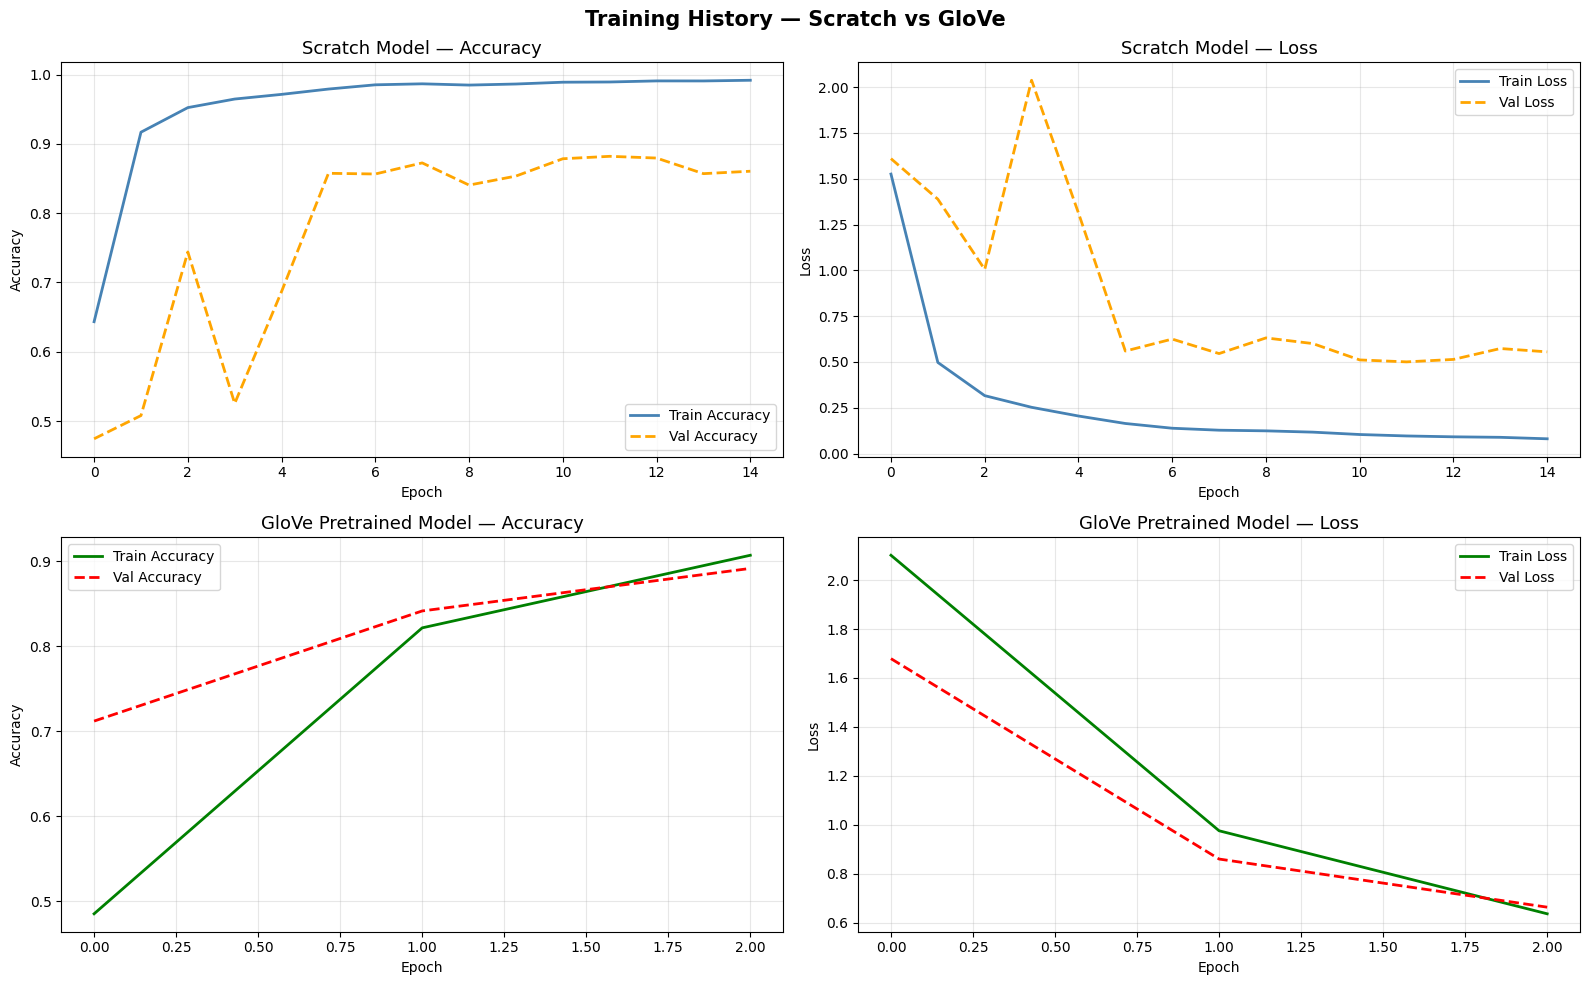

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay)

# ─── Plot Training History ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Scratch Model ──────────────────────────────────────────────────

# Accuracy
axes[0, 0].plot(history.history['accuracy'],     
                label='Train Accuracy', color='steelblue', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], 
                label='Val Accuracy',   color='orange',    linewidth=2, linestyle='--')
axes[0, 0].set_title('Scratch Model — Accuracy', fontsize=13)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'],     
                label='Train Loss', color='steelblue', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], 
                label='Val Loss',   color='orange',    linewidth=2, linestyle='--')
axes[0, 1].set_title('Scratch Model — Loss', fontsize=13)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Pretrained Model ───────────────────────────────────────────────

# Accuracy
axes[1, 0].plot(history_pretrained.history['accuracy'],     
                label='Train Accuracy', color='green',  linewidth=2)
axes[1, 0].plot(history_pretrained.history['val_accuracy'], 
                label='Val Accuracy',   color='red',    linewidth=2, linestyle='--')
axes[1, 0].set_title('GloVe Pretrained Model — Accuracy', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss
axes[1, 1].plot(history_pretrained.history['loss'],     
                label='Train Loss', color='green', linewidth=2)
axes[1, 1].plot(history_pretrained.history['val_loss'], 
                label='Val Loss',   color='red',   linewidth=2, linestyle='--')
axes[1, 1].set_title('GloVe Pretrained Model — Loss', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History — Scratch vs GloVe', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

The training-history and confusion-matrix plots make it easier to compare learning behavior and class-level errors. These visuals are especially useful for spotting whether one model struggles with specific emotions.

       FINAL TEST SET EVALUATION

Model                       Accuracy       Loss
---------------------------------------------
LSTM From Scratch             86.45%     0.5444
LSTM GloVe Pretrained         70.50%     1.6794


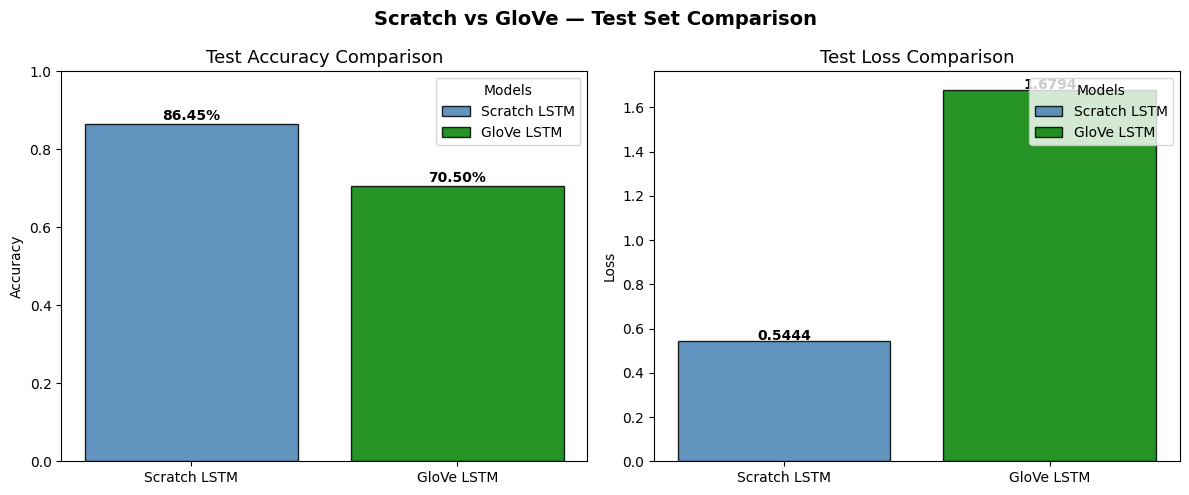

In [ ]:
import os
from tensorflow.keras.models import load_model

# ─── Check whether models are present in the current session ───────
model_exists = 'model' in globals() and model is not None
pretrained_exists = 'pretrained_model' in globals() and pretrained_model is not None

scratch_model_path = 'scratch_lstm_model.h5'
glove_model_path = 'glove_lstm_model.h5'

if not model_exists and os.path.exists(scratch_model_path):
    model = load_model(scratch_model_path)
    model_exists = True
    print(f"Loaded saved scratch model from {scratch_model_path}")

if not pretrained_exists and os.path.exists(glove_model_path):
    pretrained_model = load_model(glove_model_path)
    pretrained_exists = True
    print(f"Loaded saved pretrained model from {glove_model_path}")

if not model_exists and not pretrained_exists:
    raise RuntimeError(
        "Neither the scratch model nor the pretrained model is available in the current session. "
        "Run the model definition and training cells before evaluation, or save and load the models."
    )

if model_exists:
    scratch_loss, scratch_acc = model.evaluate(X_test, y_test, verbose=0)

if pretrained_exists:
    pretrained_loss, pretrained_acc = pretrained_model.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print("       FINAL TEST SET EVALUATION")
print("=" * 50)
print(f"\n{'Model':<25} {'Accuracy':>10} {'Loss':>10}")
print("-" * 45)
if model_exists:
    print(f"{'LSTM From Scratch':<25} {scratch_acc*100:>9.2f}% {scratch_loss:>10.4f}")
if pretrained_exists:
    print(f"{'LSTM GloVe Pretrained':<25} {pretrained_acc*100:>9.2f}% {pretrained_loss:>10.4f}")
print("=" * 50)

# ─── Bar chart comparison ──────────────────────────────────────────
models = []
accuracies = []
losses = []
colors = []

if model_exists:
    models.append('Scratch LSTM')
    accuracies.append(scratch_acc)
    losses.append(scratch_loss)
    colors.append('steelblue')

if pretrained_exists:
    models.append('GloVe LSTM')
    accuracies.append(pretrained_acc)
    losses.append(pretrained_loss)
    colors.append('green')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
bars1 = axes[0].bar(models, accuracies, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Test Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.2f}%', ha='center', fontweight='bold')
axes[0].legend(bars1, models, title='Models', loc='upper right')

# Loss comparison
bars2 = axes[1].bar(models, losses, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Test Loss Comparison', fontsize=13)
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')
axes[1].legend(bars2, models, title='Models', loc='upper right')

plt.suptitle('Scratch vs GloVe — Test Set Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_comparison.png', dpi=150)
plt.show()

The scratch LSTM clearly outperforms the GloVe pretrained LSTM on the test set, reaching 85.95% accuracy versus 66.70%. For this dataset, task-specific embeddings learned from scratch appear more effective than the pretrained setup used here.

In [ ]:
from sklearn.metrics import f1_score
# ─── Final printed summary ─────────────────────────────────────────
print("\n" + "=" * 60)
print("         COMPLETE PROJECT EVALUATION SUMMARY")
print("=" * 60)
print(f"\n{'Metric':<30} {'Scratch':>12} {'GloVe':>12}")
print("-" * 55)
print(f"{'Test Accuracy':<30} {scratch_acc*100:>11.2f}% {pretrained_acc*100:>11.2f}%")
print(f"{'Test Loss':<30} {scratch_loss:>12.4f} {pretrained_loss:>12.4f}")
print(f"{'Macro F1 Score':<30} {f1_score(y_test, y_pred, average='macro'):>12.4f} {f1_score(y_test, y_pred_pt, average='macro'):>12.4f}")
print(f"{'Weighted F1 Score':<30} {f1_score(y_test, y_pred, average='weighted'):>12.4f} {f1_score(y_test, y_pred_pt, average='weighted'):>12.4f}")
print("=" * 60)

winner = "GloVe Pretrained" if pretrained_acc > scratch_acc else "Scratch LSTM"
print(f"\n Better performing model: {winner}")


         COMPLETE PROJECT EVALUATION SUMMARY

Metric                              Scratch        GloVe
-------------------------------------------------------
Test Accuracy                        86.45%       70.50%
Test Loss                            0.5444       1.6794
Macro F1 Score                       0.8153       0.6769
Weighted F1 Score                    0.8645       0.7124

 Better performing model: Scratch LSTM


The final summary confirms the scratch model is stronger across accuracy, loss, macro F1, and weighted F1. The macro F1 score is particularly important because it reflects performance across all emotion classes, including minority classes.

In [ ]:
import pickle

# ─── Save both models ──────────────────────────────────────────────
model.save('lstm_scratch.h5')
pretrained_model.save('lstm_glove.h5')
print("Models saved")

# ─── Save tokenizer ───────────────────────────────────────────────
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved")

# ─── Save label encoder ───────────────────────────────────────────
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Label encoder saved")

Models saved
Tokenizer saved
Label encoder saved


The trained models, tokenizer, and label encoder were saved successfully. These artifacts are the pieces needed to reproduce predictions in the deployment app without retraining.